In [94]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.linalg import cholesky
n = 10**4  # Number of samples
h = 0.4    # Parameter h
ts = np.arange(1, 101)  # Time steps from 1 to 100
dt = np.diff(ts)  # Step size (this will give an array of length len(ts)-1)

def f(s, t):
    return 1 * (t**(2*h) + s**(2*h) - np.abs(s - t)**(2*h))
S = np.array([[f(s, t) for t in ts] for s in ts])
A = cholesky(S, lower=False)
xi = np.random.randn(len(ts), n)
X = A.T @ xi
xi = np.random.randn(len(ts), n) 
Y = A.T @ xi

Z = np.dstack((X,Y))

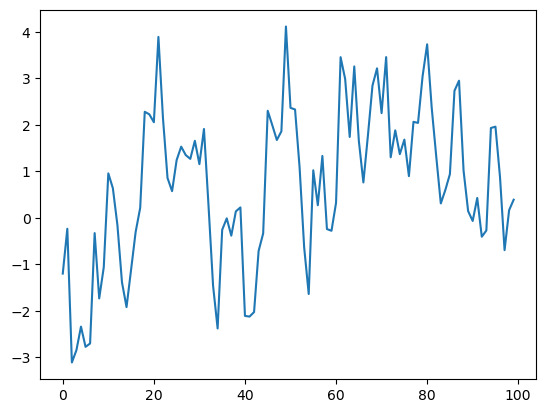

In [2]:
fig, ax = plt.subplots()
ax.plot(X[:,20])

In [3]:

def tamsd(X):
    ln, n = X.shape[:2]
    msd = np.empty((ln - 1, n), dtype=X.dtype)
    if X.ndim == 3:
        for j in range(n):
            for i in range(1, ln):
                msd[i - 1, j] = np.mean(
                    np.sum((X[:ln - i, j, :] - X[i:, j, :]) ** 2, axis = 1), axis=0
                )
    else:
        for j in range(n):
            for i in range(1, ln):
                msd[i - 1, j] = np.mean((X[:ln - i, j] - X[i:, j]) ** 2)

    
    return msd

In [4]:
np.shape(Z)

(100, 10000, 2)

In [95]:
msd = tamsd(Z)

In [45]:
msd

array([[ 3.57064328,  4.68136712,  3.79806522, ...,  4.35404562,
         3.5740789 ,  3.82314783],
       [ 5.62648484,  6.26524868,  6.25399484, ...,  5.56032802,
         5.27490027,  5.33968205],
       [ 7.19343345,  7.47490273,  7.97484734, ...,  6.82778672,
         7.07454281,  6.0250873 ],
       ...,
       [22.35517056, 42.28237001, 80.03847628, ..., 25.07470454,
        12.80304167, 51.84638439],
       [17.4265654 , 29.1899842 , 86.62879638, ..., 28.81335545,
        21.93485236, 56.73431278],
       [21.56779061, 24.62768765, 55.77740223, ..., 22.77126129,
         8.7756942 , 47.93884826]], shape=(99, 10000))

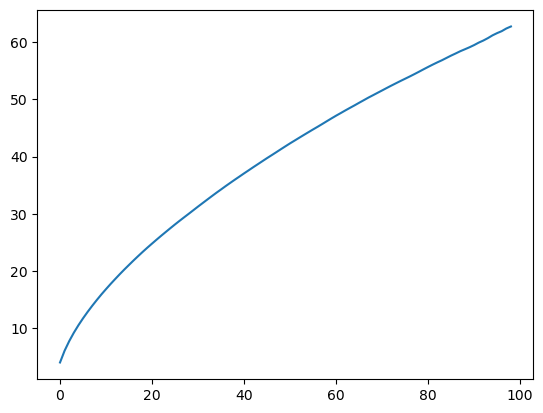

In [6]:
fig, ax = plt.subplots()
ax.plot(np.mean(msd,axis=1))

In [97]:
def fit_ols(tamsd, dim, Δt, w=None):
    if w is None:
        w = max(5, tamsd.shape[0] // 10)
    
    Ts = np.column_stack((np.ones(w), np.log10(Δt * np.arange(1, w + 1))))
    estPar = np.linalg.inv(Ts.T @ Ts) @ Ts.T @ np.log10(tamsd[:w, :])
    estPar[0, :] -= np.log10(2 * dim)
    return estPar

In [100]:
ols = fit_ols(msd,2,1)
np.mean(ols,axis=1)

array([-2.43610240e-04,  7.91201597e-01])

In [ ]:
def incrCov(ts, i, j, k, l, K):
    a, b, c, d = ts[i], ts[j], ts[k], ts[l]
    return K(a, b) + K(a + c, b + d) - K(a, b + d) - K(a + c, b)

@njit
def theorCovEff(ts, k, l, ln, alpha):
    K = lambda s, t: 2 * np.minimum(s, t) if np.abs(alpha - 1.0) < 1e-8 else (s**alpha + t**alpha - np.abs(s - t)**alpha)
    if k > l:
        k, l = l, k
    N1 = lambda h,k,l,ln: ln - l - h + 1
    N2 = lambda h,k,l,ln: (ln - l) if h <= l - k + 1 else (ln - k - h + 1)

    #sum1 = sum((ln - l - h + 1) * incrCov(ts, 0, h-1, k-1, l-1, K)**2 for h in range(2, ln - l + 1))
    #sum2 = sum(( (ln - l) if h <= l - k + 1 else (ln - k - h + 1) ) * incrCov(ts, h-1, 0, k-1, l-1, K)**2 for h in range(1, ln - k + 1))
    S1 = 0.
    for h in range(2, ln - l + 1):
        S1 += N1(h,k,l,ln) * (K(ts[0], ts[h-1]) + K(ts[0] + ts[k-1], ts[h-1] + ts[l-1]) - K(ts[0], ts[h-1] + ts[l-1]) - K(ts[0] + ts[k-1], ts[h-1]))**2
    S2 = 0.
    for  h in range(1, ln - k + 1):
        S2 += N2(h,k,l,ln) * (K(ts[h-1], ts[0]) + K(ts[h-1] + ts[k-1], ts[0] + ts[l-1]) - K(ts[h-1], ts[0] + ts[l-1]) - K(ts[h-1] + ts[k-1], ts[0]))**2
    return 2 / ((ln - k) * (ln - l)) * (S1 + S2)

In [10]:
@njit
def errCov(ts, dim, alpha, logBase=10):
    """
    Covariance of errors of TA-MSD and log TA-MSD. Data is assumed to come from FBM.
    """
    K = lambda s, t: 2 * np.minimum(s, t) if np.abs(alpha - 1.0) < 1e-8 else (s**alpha + t**alpha - np.abs(s - t)**alpha)
    

    ln = len(ts)
    errC = np.empty((ln - 1, ln - 1), dtype=np.float64)
    logErrCov = np.empty((ln - 1, ln - 1), dtype=np.float64)

    for i in range(ln - 1):
        for j in range(i, ln - 1):

            c = theorCovEff(ts, i + 1, j + 1, ln, alpha) 
            errC[i, j] = dim * c
            logErrCov[i, j] = c / (dim * K(ts[i], ts[i]) * K(ts[j], ts[j]) * (np.log(logBase) ** 2))
            errC[j, i] = errC[i, j]
            logErrCov[j, i] = logErrCov[i, j]


    return errC, logErrCov

In [11]:
c = errCov(np.arange(1,101), 1, 0.7)

In [12]:
def incrCov(ts, i, j, k, l, K):
    a, b, c, d = ts[i], ts[j], ts[k], ts[l]
    return K(a, b) + K(a + c, b + d) - K(a, b + d) - K(a + c, b)

@njit
def crossCovEff(ts, k, l, ln, alpha):
    K = lambda s, t: 2 * np.minimum(s, t) if np.abs(alpha - 1.0) < 1e-8 else (s**alpha + t**alpha - np.abs(s - t)**alpha)
    if k > l:
        k, l = l, k
    N1 = lambda h: ln - l - h + 1
    N2 = lambda h: (ln - l) if h <= l - k + 1 else (ln - k - h + 1)

    S1 = 0.
    for h in range(2, ln - l + 1):
        S1 += N1(h) * ( K(ts[0], ts[h-1]) + K(ts[0] + ts[k-1], ts[h-1] + ts[l-1]) - K(ts[0], ts[h-1] + ts[l-1]) - K(ts[0] + ts[k-1], ts[h-1]) ) * ((h == 1) + (1 + k == h + l) - (1 == h + l) - (1 + k == h) ) 
        #S1 += N1(h) * incr_cov(ts, 1, h, k, l, K) * ((h == 1) + (h + k == 1 + l) - (h == 1 + l) - (h + k == 1) ) 
    S2 = 0.
    for h in range(1, ln - k + 1):
        S2 += N2(h) * ( K(ts[h-1], ts[0]) + K(ts[h-1] + ts[k-1], ts[0] + ts[l-1]) - K(ts[h-1], ts[0] + ts[l-1]) - K(ts[h-1] + ts[k-1], ts[0]) ) * ((h == 1) + (h + k == 1 + l) - (h == 1 + l) - (h + k == 1)) 
        #S2 += N2(h) * incr_cov(ts, h, 1, k, l, K) * ((h == 1) + (h + k == 1 + l) - (h == 1 + l) - (h + k == 1)) 

    return 4 / ((ln - k) * (ln - l)) * (S1 + S2)

@njit
def crossCov(ts, dim, alpha):

    ln = len(ts)
    cov = np.empty((ln - 1, ln - 1), dtype=np.float64)
    for i in range(1, ln):
        for j in range(i, ln):
            cov[i - 1, j - 1] = dim * crossCovEff(ts, i, j, ln, alpha)
            cov[j - 1, i - 1] = cov[i - 1, j - 1]

    return cov

In [51]:
c = crossCov(np.arange(1,101),2,0.7)

In [52]:
np.shape(c)

(99, 99)

In [14]:
@njit
def noiseCov(ln, k, l):
    """
    Covariance of 1D iid noise TA-MSD
    """
    if k > l:
        l, k = k, l
    if k == l:
        return 4 / (ln - k) ** 2 * ((3 * ln - 4 * k) if ln >= 2 * k else (2 * ln - 2 * k))
    else:
        return 4 / ((ln - k) * (ln - l)) * ((2 * ln - k - 2 * l) if ln >= k + l else (ln - l))

In [57]:
noiseCov(100,1,20)

0.0803030303030303

In [101]:
@njit
def fit_gls_base(tamsd, dim, Δt, init_α, precompute=True, precompute_alphas=np.arange(0.1, 1.62, 0.02)):
    """
    Fitting TA-MSD with the GLS method.
    Input:
    - tamsd: ln-1×n  matrix containing the entire TA-MSDs of the n length ln sample trajectories
    - dim: original trajectory dimension (1,2 or 3)
    - Δt: sampling interval
    - init_α: initial approximate values of anomalous exponent
    Optional input:
    - precompute = True: if true first tabularise error covariances, if false calculate it for trajectories (could be computationally demanding)
    - precompute_αs = 0.1:0.02:1.6: points at which precompute
    Output:
    - gls: 2×n matrix values of (log10 D, α) estimates
    - errCov: 2×2×n matrix with estimated parameter error covariances 
    """
    ln, n = tamsd.shape[0] + 1, tamsd.shape[1]  # ln is of original trajectory
    ts = Δt * np.arange(1, ln + 1)
    Ts = np.vstack((np.ones(ln - 1), np.log10(ts[:ln - 1]))).T
    gls = np.empty((2, n), dtype=np.float64)
    fitCov = np.empty((2, 2, n), dtype=np.float64)
    lmsd = np.log10(tamsd)

    if precompute:
        # precompute covariances
        na = len(precompute_alphas)
        errC = np.empty((ln - 1, ln - 1, na), dtype=np.float64)
        iC = np.empty((ln - 1, ln - 1, na), dtype=np.float64)
        bias = np.empty((ln - 1, na), dtype=np.float64)

        for k in range(na):
            c = errCov(ts, dim, precompute_alphas[k])[1]
            errC[:, :, k] = c
            bias[:, k] = -np.log(10) * np.diag(c) / 2
            iC[:, :, k] = np.linalg.inv(c)

        # estimate
        for i in range(n):
            j0 = np.argmin(np.abs(precompute_alphas - init_α[i]))
            gR = np.linalg.inv(Ts.T @ iC[:, :, j0] @ Ts) @ Ts.T @ iC[:, :, j0]
            gls[:, i] = gR @ (lmsd[:, i] - bias[:, j0])

            j1 = np.argmin(np.abs(precompute_alphas - gls[1, i]))
            fitCov[:, :, i] = np.linalg.inv(Ts.T @ iC[:, :, j1] @ Ts)
    else:
        for i in range(n):
            errC = errCov(ts, dim, init_α[i])[1]
            bias = -np.log(10) * np.diag(errC) / 2
            iC = np.linalg.inv(errC)
            gR = np.linalg.inv(Ts.T @ iC @ Ts) @ Ts.T @ iC
            gls[:, i] = gR @ (lmsd[:, i] - bias)
            errC2 = errCov(ts, dim, gls[1, i])[1]
            fitCov[:, :, i] = np.linalg.inv(Ts.T @ np.linalg.inv(errC2) @ Ts)

    gls[0, :] -= np.log10(2 * dim)
    return gls, fitCov

In [ ]:
gls, cov = fit_gls(msd,2,1,np.full(10**4,0.8))

In [ ]:
gls, cov = fit_gls(msd[:,0:200],2,1,np.full(10**4,0.8), precompute = False)

In [104]:
np.mean(gls,axis=1)

array([1.06239959e-04, 8.01940169e-01])

In [29]:
cov[:,:,20]

array([[ 0.00219355, -0.00131614],
       [-0.00131614,  0.00611035]])

In [17]:
np.log10([-1, 2])

C:\Users\jslez\AppData\Local\Temp\ipykernel_17052\3047732471.py:1: RuntimeWarning: invalid value encountered in log10
  np.log10([-1, 2])


array([    nan, 0.30103])

In [76]:
fit = gls[0]
np.mean(fit[0,:])
np.cov(fit)

array([[ 0.0020869 , -0.0011214 ],
       [-0.0011214 ,  0.00658091]])

In [105]:

@njit
def fit_gls_noise(tamsd, dim, Δt, init_α, init_D, σ, precompute=True, precompute_alphas=np.arange(0.1, 1.62, 0.02)):
    ln, n = tamsd.shape[0] + 1, tamsd.shape[1]
    na = len(precompute_alphas)
    ts = Δt * np.arange(1, ln + 1)
    Ts = np.column_stack((np.ones(ln - 1), np.log10(ts[:ln - 1])))
    gls = np.empty((2, n), dtype=np.float64)
    fitCov = np.empty((2, 2, n), dtype=np.float64)
 
    lmsd = np.log10(tamsd - 2 * dim * σ**2)

    noiseC = np.empty((ln - 1, ln - 1), dtype=np.float64) 
    for i in range(1,ln-1):
        for j in range(1,ln-1):
            noiseC[i-1,j-1] = noiseCov(ln,i,j)
            noiseC[j-1,i-1] = noiseC[i-1,j-1]

    if precompute:
        orgC = np.empty((ln - 1, ln - 1, na), dtype=np.float64)  # pure FBM, no noise, no log scale
        crossC = np.empty((ln - 1, ln - 1, na), dtype=np.float64)  # cross term in cov

        for k in range(na):
            orgC[:, :, k] = errCov(ts, dim, precompute_alphas[k])[0]
            crossC[:, :, k] = crossCov(ts, dim, precompute_alphas[k])

        for i in range(n):
            α0, D0 = init_α[i], init_D[i]
            j0 = np.argmin(np.abs(precompute_alphas - α0))
            errC0 = (1 / (np.log(10)**2)) * (D0**2 * orgC[:, :, j0] + σ**2 * D0 * crossC[:, :, j0] + σ**4 * dim * noiseC) / ((2 * D0 * dim * ts[:ln - 1]**(α0)) * (2 * D0 * dim * ts[:ln - 1][:, None]**(α0)))
            mask = ~np.isnan(lmsd[:, i])
            iC0 = np.linalg.inv(errC0[mask][:, mask])
            bias = -np.log(10) * np.diag(errC0) / 2
            gR = np.linalg.inv(Ts[mask, :].T @ iC0 @ Ts[mask, :]) @ Ts[mask, :].T @ iC0
            gls[:, i] = gR @ (lmsd[mask, i] - bias[mask])
            gls[0, i] -= np.log10(2 * dim)

            α1, D1 = gls[1, i], 10**gls[0, i]
            j1 = np.argmin(np.abs(precompute_alphas - α1))
            errC1 = (1 / (np.log(10)**2)) * (D1**2 * orgC[:, :, j1] + σ**2 * D1 * crossC[:, :, j1] + σ**4 * dim * noiseC) / ((2 * D1 * dim * ts[:ln - 1]**(α1)) * (2 * D1 * dim * ts[:ln - 1][:, None]**(α1))) 
            iC1 = np.linalg.inv(errC1)
            fitCov[:, :, i] = np.linalg.inv(Ts.T @ iC1 @ Ts)
    else:
        for i in range(n):
            α0, D0 = init_α[i], init_D[i]
            orgC = errCov(ts, dim, α0)[0]
            crossC = crossCov(ts, dim, α0)
            errC0 = (1 / (np.log(10)**2)) * (D0**2 * orgC + σ**2 * D0 * crossC + σ**4 * dim * noiseC) / ((2 * D0 * dim * ts[:ln - 1]**(α0)) * (2 * D0 * dim * ts[:ln - 1][:, None]**(α0)))
            
            bias = -np.log(10) * np.diag(errC0) / 2

            mask = ~np.isnan(lmsd[:, i])
            iC0 = np.linalg.inv(errC0[mask][:, mask])
            gR = np.linalg.inv(Ts[mask, :].T @ iC0 @ Ts[mask, :]) @ Ts[mask, :].T @ iC0
            gls[:, i] = gR @ (lmsd[mask, i] - bias[mask])
            gls[0, i] -= np.log10(2 * dim)

            α1, D1 = gls[1, i], 10**gls[0, i]
            orgC = errCov(ts, dim, α1)[0]
            crossC = crossCov(ts, dim, α1)
            errC1 = (1 / (np.log(10)**2)) * (D1**2 * orgC + σ**2 * D1 * crossC + σ**4 * dim * noiseC) / ((2 * D1 * dim * ts[:ln - 1]**(α1)) * (2 * D1 * dim * ts[:ln - 1][:, None]**(α1)))
            fitCov[:, :, i] = np.linalg.inv(Ts.T @ np.linalg.inv(errC1) @ Ts)

    return gls, fitCov

In [111]:
X2 = np.sqrt(5)*X + 1*np.random.randn(10**4)
msd2 = tamsd(X2)

In [114]:
gls, cov = fit_gls_noise(msd2[:,1:200],1,1,np.full(10**4,0.8),np.full(10**4,5.0),1.0,precompute=False)

In [116]:
np.mean(gls,axis=1)

array([0.59885332, 0.91357524])

In [110]:
10**1.38

23.9883291901949